In [1]:
import sapphire

In [2]:
from sapphire.utils import read_config
config = read_config.get({'path_config':'/mnt/ceph/users/vpandya/sapphire/scripts/config.yaml'})

### now modify for latin hypercube sampling
config['runtype'] = 'sampling'
config['sampling_config']['method'] = 'latin_hypercube'
config['rng_sample'] = 1 # can change this random seed
config['sampling_config']['Nsamples'] = 100

params_bounds = config['sampling_config']['params_bounds']
params_bounds['alpha0_M'] = [-4.0,0.0]
params_bounds['alpha0_E'] = [-4.0,0.0]
params_bounds['alpha0_SF'] = [-4.0,0.0]
params_bounds['alpha0_Z'] = [-4.0,0.0]
# params_bounds['beta_SF'] = [-2.0,0.0]
# params_bounds['alphaz_M'] = [-2.0,0.0]
# params_bounds['beta_M'] = [-2.0,1.0]
# params_bounds['alphaz_E'] = [-2.0,0.0]
# params_bounds['beta_E'] = [-2.0,0.0]
# params_bounds['alphaz_SF'] = [-2.0,0.0]
# params_bounds['alphaz_Z'] = [-2.0,0.0]
# params_bounds['beta_Z'] = [-2.0,0.0]
config['sampling_config']['params_bounds'] = params_bounds

# we'll continue to use the same default bounds for uniform random sampling as we did for inference
config['sampling_config']

{'method': 'latin_hypercube',
 'posterior_file': 'numpyro_mix_chain%s_111_slope4_mzrgas.npz',
 'Nsamples': 100,
 'params_bounds': {'A_M': [-2.0, 1.0],
  'alpha0_M': [-4.0, 0.0],
  'A_E': [-2.0, 0.0],
  'alpha0_E': [-4.0, 0.0],
  'A_SF': [0.0, 1.1],
  'alpha0_SF': [-4.0, 0.0],
  'A_Z': [-2.0, 0.0],
  'alpha0_Z': [-4.0, 0.0]}}

In [3]:
out_sapphire = sapphire.run(config)
sol = out_sapphire[0]

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'manual',
                            'engine': 'nuts',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': True,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_name': 'manga',
    'output_path': '/mnt/ceph/u

E0325 13:06:13.020947 1306894 rendezvous.cc:108] [id=2] This thread has been waiting for `[3] [rank=3] [run_id=811712727] Initialize clique: devices=4:[0,1,2,3]; is_p2p=false; local_participants=4; incarnations=[]` for 10 seconds and may be stuck. All 4 threads joined the rendezvous, however the leader has not marked the rendezvous as completed. Leader can be deadlocked inside the rendezvous callback.
E0325 13:06:13.020945 1306888 rendezvous.cc:108] [id=0] This thread has been waiting for `[1] [rank=1] [run_id=811712727] Initialize clique: devices=4:[0,1,2,3]; is_p2p=false; local_participants=4; incarnations=[]` for 10 seconds and may be stuck. All 4 threads joined the rendezvous, however the leader has not marked the rendezvous as completed. Leader can be deadlocked inside the rendezvous callback.
E0325 13:06:13.020950 1306891 rendezvous.cc:108] [id=1] This thread has been waiting for `[2] [rank=2] [run_id=811712727] Initialize clique: devices=4:[0,1,2,3]; is_p2p=false; local_particip

[[ 9.83305598  8.14228553  9.75204285 57.62858731  7.72278763  6.14729956
   7.47362735]]
full-batch initial jit+sol took 31.046 sec


E0325 13:06:13.431129 1306888 rendezvous.cc:130] [id=0] This thread is unstuck waiting for `[1] [rank=1] [run_id=811712727] Initialize clique: devices=4:[0,1,2,3]; is_p2p=false; local_participants=4; incarnations=[]` after 10.410416953s. All threads joined the rendezvous on time however the leader took long time to complete it. Warning above was a false-positive. Perhaps the timeout is too short.
E0325 13:06:13.431225 1306894 rendezvous.cc:130] [id=2] This thread is unstuck waiting for `[3] [rank=3] [run_id=811712727] Initialize clique: devices=4:[0,1,2,3]; is_p2p=false; local_participants=4; incarnations=[]` after 10.410400435s. All threads joined the rendezvous on time however the leader took long time to complete it. Warning above was a false-positive. Perhaps the timeout is too short.
E0325 13:06:13.431227 1306891 rendezvous.cc:130] [id=1] This thread is unstuck waiting for `[2] [rank=2] [run_id=811712727] Initialize clique: devices=4:[0,1,2,3]; is_p2p=false; local_participants=4; 

[[ 9.83305598  8.14228553  9.75204285 57.62858731  7.72278763  6.14729956
   7.47362735]]
full-batch jitted sol took 11.706 sec
returning sol...
Finished in 1.0 min -- thank you for using sapphire!


In [13]:
### re-run w/o pre-enriched halo inflows

config['params_fixed_astro']['A_Zin_halo'] = 0.0 
config['rng_sample'] = 1
config['sampling_config']['Nsamples'] = 100

out_sapphire2 = sapphire.run(config)
sol2 = out_sapphire2[0]

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'manual',
                            'engine': 'nuts',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': True,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_name': 'manga',
    'output_path': '/mnt/ceph/u

In [5]:
### read obs_stats to get x0 and bw for NW regression
from sapphire.utils import read_obs
obs_mix = read_obs.read_mix({'data_path':'/mnt/ceph/users/vpandya/sapphire/data/','obs_name':'mix'}) # behroozi SMHM

In [6]:
### do nadaraya-watson regression
import jax
from sapphire.summaries import gaussian_kernel_regression as gkr

# we will vmap over the summarize_mock function so all 100 solutions get summarized at once
prior_gkrs = jax.vmap(gkr.summarize_mock,in_axes=(0,None))(sol,obs_mix)

# following return signature of summarize_mock
(mock_x0_smhm, mock_bw_smhm, mock_avg_smhm, mock_err_smhm,
 mock_x0_fgas, mock_bw_fgas, mock_avg_fgas, mock_err_fgas,
 mock_x0_mzr, mock_bw_mzr, mock_avg_mzr, mock_err_mzr,
 mock_x0_sfms, mock_bw_sfms, mock_avg_sfms, mock_err_sfms,
 mock_x0_mzr_gas, mock_bw_mzr_gas, mock_avg_mzr_gas, mock_err_mzr_gas) = prior_gkrs

In [15]:
### repeat for no pre-enriched halo inflows
prior_gkrs2 = jax.vmap(gkr.summarize_mock,in_axes=(0,None))(sol2,obs_mix)

# following return signature of summarize_mock
(mock_x0_smhm2, mock_bw_smhm2, mock_avg_smhm2, mock_err_smhm2,
 mock_x0_fgas2, mock_bw_fgas2, mock_avg_fgas2, mock_err_fgas2,
 mock_x0_mzr2, mock_bw_mzr2, mock_avg_mzr2, mock_err_mzr2,
 mock_x0_sfms2, mock_bw_sfms2, mock_avg_sfms2, mock_err_sfms2,
 mock_x0_mzr_gas2, mock_bw_mzr_gas2, mock_avg_mzr_gas2, mock_err_mzr_gas2) = prior_gkrs2

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


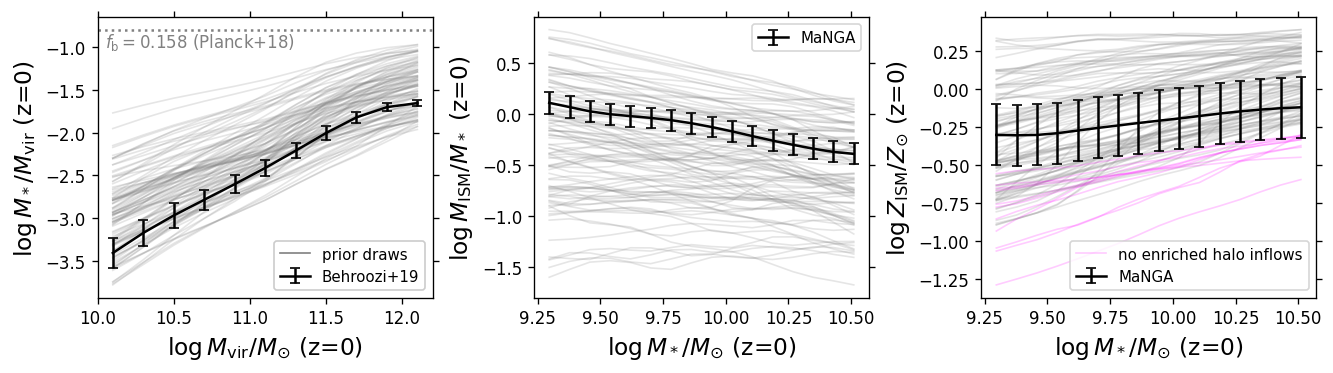

In [12]:
color_obs = 'k'
color_prior = 'gray'

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),constrained_layout=True)
ax_smhm, ax_fgas, ax_mzr = axes

##### first the data/constraints
ax_smhm.errorbar(obs_mix[0],obs_mix[2],yerr=obs_mix[3],
             fmt='-',color=color_obs,capsize=3,zorder=np.inf,label='Behroozi+19')

# axes[0].set_xscale('log')
ax_smhm.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$ (z=0)',fontsize=14)
ax_smhm.set_ylabel(r'$\log M_*/M_{\rm vir}$ (z=0)',fontsize=14)

ax_fgas.errorbar(obs_mix[4],obs_mix[6],yerr=obs_mix[7],
                 fmt='-',capsize=3,zorder=np.inf,color=color_obs,label='MaNGA')

# plt.xscale('log')
ax_fgas.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_fgas.set_ylabel(r'$\log M_{\rm ISM}/M_*$ (z=0)',fontsize=14)

ax_mzr.errorbar(obs_mix[16],obs_mix[18],yerr=obs_mix[19],
                 fmt='-',capsize=3,zorder=np.inf,color=color_obs,label='MaNGA')

ax_mzr.set_xlabel(r'$\log M_*/M_{\odot}$ (z=0)',fontsize=14)
ax_mzr.set_ylabel(r'$\log Z_{\rm ISM}/Z_{\odot}$ (z=0)',fontsize=14)

##### plot random draws from posterior

for inum,ival in enumerate(range(mock_x0_smhm.shape[0])):
    
    ax_smhm.plot(mock_x0_smhm[ival],mock_avg_smhm[ival],'-',color=color_prior,alpha=0.2,lw=1,
                label=r'prior draws' if inum==0 else '__none__')

    ax_fgas.plot(mock_x0_fgas[ival],mock_avg_fgas[ival],'-',color=color_prior,alpha=0.2,lw=1,)

    ax_mzr.plot(mock_x0_mzr_gas[ival],mock_avg_mzr_gas[ival],'-',color=color_prior,alpha=0.2,lw=1)

### further plot mzr_gas draws when turning off halo inflow pre-enrichment 
inds_plot = np.where(mock_avg_mzr_gas2[:,-1]<-0.3)[0]
for inum,ival in enumerate(inds_plot):
    if mock_avg_mzr_gas2[ival][-1] < -0.3: 
        ax_mzr.plot(mock_x0_mzr_gas2[ival],mock_avg_mzr_gas2[ival],'-',color='magenta',alpha=0.2,lw=1,
                    label=r'no enriched halo inflows' if inum==0 else '__none__')


# orig_xlim, orig_ylim = ax_smhm.get_xlim(), ax_smhm.get_ylim() 
# ax_smhm.errorbar(obs_lit[0],obs_lit[2],yerr=obs_lit[3],fmt='-',color='c',capsize=3,zorder=np.inf,label='Behroozi+19',alpha=0.9)
# ax_smhm.set_xlim(orig_xlim)
# ax_smhm.set_ylim(orig_ylim)


leg = ax_smhm.legend(fontsize=9,fancybox=True,framealpha=1,ncol=1,loc='lower right')
leg.get_lines()[0].set_alpha(1.0)

ax_fgas.legend(fontsize=9)
ax_mzr.legend(fontsize=9)

from astropy.cosmology import Planck18
fb_planck18 = Planck18.Ob0/Planck18.Om0
ax_smhm.axhline(np.log10(fb_planck18),color='gray',ls=':')
ax_smhm.text(10.05,-1.0,r'$f_{\rm b}=0.158$ (Planck+18)',color='gray',fontsize=10)

# plt.savefig(config['output_path']+'figures/prior_predictive_checks_mzrgas_noAZinhalo.png',
#             bbox_inches='tight',dpi=300,facecolor='w')